In [1]:
import numpy as np

# Parameters
epsilon_start = 1.0
epsilon_min = 0.1
epsilon_decay = 0.9999995

# Calculate the number of steps required
time_steps = np.log(epsilon_min / epsilon_start) / np.log(epsilon_decay)

print(time_steps)

4605169.0350743


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
num_rounds = 2  # Number of rounds in each game
valuation = 10  # Maximum value that agents can bid for an item
num_actions = 10  # Total number of discrete actions (bids) each agent can take
actions = np.arange(num_actions)  # Array representing possible actions (bids)
epsilon_start = 1.0  # Initial exploration rate for the epsilon-greedy strategy
epsilon_min = 0.01  # Minimum value for epsilon to ensure some exploration
epsilon_decay = 0.9999995  # Decay factor for epsilon after each game
learning_rate = 0.1  # Rate at which the agent updates its Q-values based on new information
discount_rate = 1.0  # Factor that discounts future rewards compared to immediate rewards
lambda_ = 0.9  # Eligibility trace decay factor for updating Q-values
num_games = 10_000_000  # Total number of games to train the agents
verbose_interval = 10000  # Interval at which training progress is printed out

# Initialize Q-tables
q_table1 = np.zeros((num_rounds + 1, 2, num_actions))
q_table2 = np.zeros((num_rounds + 1, 2, num_actions))

# Train function for two agents
def train_agents(q_table1, q_table2):
    epsilon = epsilon_start
    reward_history_q1 = []
    reward_history_q2 = []
    for game in range(num_games):
        e_trace1 = np.zeros_like(q_table1)
        e_trace2 = np.zeros_like(q_table2)

        t = num_rounds
        s = 0
        current_bid_q1 = 0
        current_bid_q2 = 0

        while t > 0:
            state_q1 = (t, s)
            state_q2 = (t, 1 - s)

            action_q1 = np.random.choice(actions) if np.random.rand() < epsilon else actions[np.argmax(q_table1[state_q1])]
            action_q2 = np.random.choice(actions) if np.random.rand() < epsilon else actions[np.argmax(q_table2[state_q2])]

            current_bid_q1 += action_q1
            current_bid_q2 += action_q2

            s = 1 if current_bid_q1 >= current_bid_q2 else 0

            e_trace1 *= discount_rate * lambda_
            e_trace2 *= discount_rate * lambda_

            e_trace1[state_q1][action_q1] += 1
            e_trace2[state_q2][action_q2] += 1

            if t == 1:
                reward_q1 = (valuation - current_bid_q1) if (current_bid_q1 > current_bid_q2) and (current_bid_q1 <= valuation) else 0
                reward_q2 = (valuation - current_bid_q2) if (current_bid_q2 > current_bid_q1) and (current_bid_q2 <= valuation) else 0

                delta_q1 = reward_q1 - q_table1[state_q1][action_q1]
                delta_q2 = reward_q2 - q_table2[state_q2][action_q2]

                q_table1 += learning_rate * delta_q1 * e_trace1
                q_table2 += learning_rate * delta_q2 * e_trace2

            t -= 1

        reward_history_q1.append(reward_q1)
        reward_history_q2.append(reward_q2)

        if (game + 1) % verbose_interval == 0:
            print(f"Game {game + 1}: Epsilon: {epsilon:.4f}, Avg Q1: {np.mean(reward_history_q1[-verbose_interval:])}, Avg Q2: {np.mean(reward_history_q2[-verbose_interval:])}")

        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    return q_table1, q_table2, reward_history_q1, reward_history_q2

# Play and visualize game function
def play_game(q_table1, q_table2):
    t = num_rounds
    s = 0
    current_bid_q1 = 0
    current_bid_q2 = 0
    highest_bids_q1 = []
    highest_bids_q2 = []

    while t > 0:
        state_q1 = (t, s)
        state_q2 = (t, 1 - s)

        action_q1 = actions[np.argmax(q_table1[state_q1])]
        action_q2 = actions[np.argmax(q_table2[state_q2])]

        current_bid_q1 += action_q1
        current_bid_q2 += action_q2

        highest_bids_q1.append(current_bid_q1)
        highest_bids_q2.append(current_bid_q2)

        s = 1 if current_bid_q1 >= current_bid_q2 else 0
        t -= 1

    reward_q1 = (valuation - current_bid_q1) if (current_bid_q1 > current_bid_q2) and (current_bid_q1 <= valuation) else 0
    reward_q2 = (valuation - current_bid_q2) if (current_bid_q2 > current_bid_q1) and (current_bid_q2 <= valuation) else 0

    return highest_bids_q1, highest_bids_q2, reward_q1, reward_q2

def visualize_game(highest_bids_q1, highest_bids_q2):
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, num_rounds+1), highest_bids_q1, 'x-', label='Q-Learning Agent 1 Highest Bids', markersize=8)
    plt.plot(range(1, num_rounds+1), highest_bids_q2, 'o-', label='Q-Learning Agent 2 Highest Bids', markersize=5)
    plt.xlabel('Round')
    plt.ylabel('Highest Bid Amount')
    plt.title('Highest Bid Progression Over Rounds')
    plt.legend()
    plt.grid(True)
    plt.show()

# Train the agents
q_table1, q_table2, reward_history_q1, reward_history_q2 = train_agents(q_table1, q_table2)

Game 10000: Epsilon: 0.9950, Avg Q1: 0.3376, Avg Q2: 0.3399
Game 20000: Epsilon: 0.9901, Avg Q1: 0.3581, Avg Q2: 0.3454
Game 30000: Epsilon: 0.9851, Avg Q1: 0.3443, Avg Q2: 0.3484
Game 40000: Epsilon: 0.9802, Avg Q1: 0.3544, Avg Q2: 0.3627
Game 50000: Epsilon: 0.9753, Avg Q1: 0.3386, Avg Q2: 0.3612
Game 60000: Epsilon: 0.9704, Avg Q1: 0.348, Avg Q2: 0.3715
Game 70000: Epsilon: 0.9656, Avg Q1: 0.3828, Avg Q2: 0.3856
Game 80000: Epsilon: 0.9608, Avg Q1: 0.3868, Avg Q2: 0.3931
Game 90000: Epsilon: 0.9560, Avg Q1: 0.3917, Avg Q2: 0.3768
Game 100000: Epsilon: 0.9512, Avg Q1: 0.39, Avg Q2: 0.3788
Game 110000: Epsilon: 0.9465, Avg Q1: 0.3991, Avg Q2: 0.3953
Game 120000: Epsilon: 0.9418, Avg Q1: 0.4063, Avg Q2: 0.4131
Game 130000: Epsilon: 0.9371, Avg Q1: 0.4359, Avg Q2: 0.4065
Game 140000: Epsilon: 0.9324, Avg Q1: 0.405, Avg Q2: 0.4187
Game 150000: Epsilon: 0.9277, Avg Q1: 0.4294, Avg Q2: 0.4214
Game 160000: Epsilon: 0.9231, Avg Q1: 0.4143, Avg Q2: 0.4434
Game 170000: Epsilon: 0.9185, Avg Q1:

KeyboardInterrupt: 

In [ ]:
# Example of playing and visualizing a game
highest_bids_q1, highest_bids_q2, reward_q1, reward_q2 = play_game(q_table1, q_table2)
visualize_game(highest_bids_q1, highest_bids_q2)
print(f"Reward for Q-Learning Agent 1: {reward_q1}")
print(f"Reward for Q-Learning Agent 2: {reward_q2}")

### adding noise bidders

Game 10000: Epsilon: 0.9950, Avg Q1: 0.2039, Avg Q2: 0.1571
Game 20000: Epsilon: 0.9901, Avg Q1: 0.2016, Avg Q2: 0.1712
Game 30000: Epsilon: 0.9851, Avg Q1: 0.2043, Avg Q2: 0.1608
Game 40000: Epsilon: 0.9802, Avg Q1: 0.202, Avg Q2: 0.1597
Game 50000: Epsilon: 0.9753, Avg Q1: 0.1904, Avg Q2: 0.1757
Game 60000: Epsilon: 0.9704, Avg Q1: 0.1785, Avg Q2: 0.1665
Game 70000: Epsilon: 0.9656, Avg Q1: 0.2104, Avg Q2: 0.1846
Game 80000: Epsilon: 0.9608, Avg Q1: 0.1948, Avg Q2: 0.1803
Game 90000: Epsilon: 0.9560, Avg Q1: 0.2127, Avg Q2: 0.1662
Game 100000: Epsilon: 0.9512, Avg Q1: 0.221, Avg Q2: 0.1779
Game 110000: Epsilon: 0.9465, Avg Q1: 0.1965, Avg Q2: 0.1856
Game 120000: Epsilon: 0.9418, Avg Q1: 0.2023, Avg Q2: 0.1847
Game 130000: Epsilon: 0.9371, Avg Q1: 0.2118, Avg Q2: 0.204
Game 140000: Epsilon: 0.9324, Avg Q1: 0.1942, Avg Q2: 0.1965
Game 150000: Epsilon: 0.9277, Avg Q1: 0.2188, Avg Q2: 0.1952
Game 160000: Epsilon: 0.9231, Avg Q1: 0.2117, Avg Q2: 0.1953
Game 170000: Epsilon: 0.9185, Avg Q1

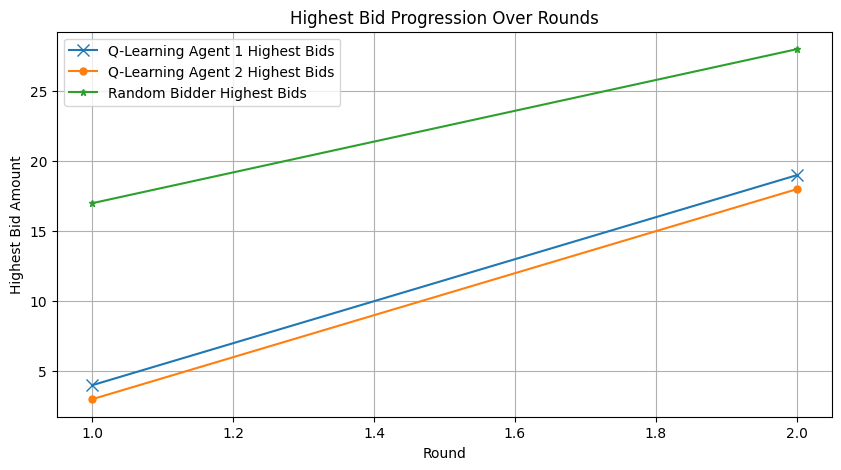

Reward for Q-Learning Agent 1: 0
Reward for Q-Learning Agent 2: 0


In [54]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
num_rounds = 2  # Number of rounds in each game
valuation = 20  # Maximum value that agents can bid for an item
num_actions = 20  # Total number of discrete actions (bids) each agent can take
actions = np.arange(num_actions)  # Array representing possible actions (bids)
epsilon_start = 1.0  # Initial exploration rate for the epsilon-greedy strategy
epsilon_min = 0.01  # Minimum value for epsilon to ensure some exploration
epsilon_decay = 0.9999995  # Decay factor for epsilon after each game
learning_rate = 0.1  # Rate at which the agent updates its Q-values based on new information
discount_rate = 1.0  # Factor that discounts future rewards compared to immediate rewards
lambda_ = 0.9  # Eligibility trace decay factor for updating Q-values
num_games = 5_000_000  # Total number of games to train the agents
verbose_interval = 10000  # Interval at which training progress is printed out

# Initialize Q-tables for two Q-learning agents
q_table1 = np.zeros((num_rounds + 1, 2, num_actions))
q_table2 = np.zeros((num_rounds + 1, 2, num_actions))

# Train function for two agents and a random third bidder
def train_agents(q_table1, q_table2):
    epsilon = epsilon_start
    reward_history_q1 = []
    reward_history_q2 = []

    for game in range(num_games):
        e_trace1 = np.zeros_like(q_table1)
        e_trace2 = np.zeros_like(q_table2)

        t = num_rounds
        s = 0  # Binary state indicating which Q-learning agent has the highest bid
        current_bid_q1 = 0
        current_bid_q2 = 0
        current_bid_random = 0

        while t > 0:
            state_q1 = (t, s)
            state_q2 = (t, 1 - s)

            # Agent 1 and Agent 2 use epsilon-greedy policy
            action_q1 = np.random.choice(actions) if np.random.rand() < epsilon else actions[np.argmax(q_table1[state_q1])]
            action_q2 = np.random.choice(actions) if np.random.rand() < epsilon else actions[np.argmax(q_table2[state_q2])]
            
            # Random third bidder chooses a random bid
            action_random = np.random.choice(actions)

            current_bid_q1 += action_q1
            current_bid_q2 += action_q2
            current_bid_random += action_random

            # Determine the highest bid between Q-learning agents (ignoring the random bidder for state updates)
            if current_bid_q1 > current_bid_q2:
                s = 0  # Bidder 1 has the highest bid
            else:
                s = 1  # Bidder 2 has the highest bid

            e_trace1 *= discount_rate * lambda_
            e_trace2 *= discount_rate * lambda_

            e_trace1[state_q1][action_q1] += 1
            e_trace2[state_q2][action_q2] += 1

            if t == 1:
                # Final round: rewards are based on the final bids
                highest_bid = max(current_bid_q1, current_bid_q2, current_bid_random)

                if highest_bid == current_bid_q1 and current_bid_q1 <= valuation:
                    reward_q1 = valuation - current_bid_q1
                    reward_q2 = 0
                elif highest_bid == current_bid_q2 and current_bid_q2 <= valuation:
                    reward_q1 = 0
                    reward_q2 = valuation - current_bid_q2
                else:
                    # Random bidder wins, both Q-learning agents get 0 reward
                    reward_q1 = 0
                    reward_q2 = 0

                delta_q1 = reward_q1 - q_table1[state_q1][action_q1]
                delta_q2 = reward_q2 - q_table2[state_q2][action_q2]

                q_table1 += learning_rate * delta_q1 * e_trace1
                q_table2 += learning_rate * delta_q2 * e_trace2

            t -= 1

        reward_history_q1.append(reward_q1)
        reward_history_q2.append(reward_q2)

        if (game + 1) % verbose_interval == 0:
            print(f"Game {game + 1}: Epsilon: {epsilon:.4f}, Avg Q1: {np.mean(reward_history_q1[-verbose_interval:])}, Avg Q2: {np.mean(reward_history_q2[-verbose_interval:])}")

        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    return q_table1, q_table2, reward_history_q1, reward_history_q2

# Play and visualize game function
def play_game(q_table1, q_table2):
    t = num_rounds
    s = 0  # Binary state for which Q-learning agent has the highest bid
    current_bid_q1 = 0
    current_bid_q2 = 0
    current_bid_random = 0
    highest_bids_q1 = []
    highest_bids_q2 = []
    highest_bids_random = []

    while t > 0:
        state_q1 = (t, s)
        state_q2 = (t, 1 - s)

        action_q1 = actions[np.argmax(q_table1[state_q1])]
        action_q2 = actions[np.argmax(q_table2[state_q2])]
        action_random = np.random.choice(actions)  # Random bidder action

        current_bid_q1 += action_q1
        current_bid_q2 += action_q2
        current_bid_random += action_random

        highest_bids_q1.append(current_bid_q1)
        highest_bids_q2.append(current_bid_q2)
        highest_bids_random.append(current_bid_random)

        # Determine the highest bid between Q-learning agents (ignoring the random bidder for state updates)
        if current_bid_q1 > current_bid_q2:
            s = 0  # Bidder 1 has the highest bid
        else:
            s = 1  # Bidder 2 has the highest bid

        t -= 1

    reward_q1 = (valuation - current_bid_q1) if (current_bid_q1 > current_bid_q2 and current_bid_q1 > current_bid_random) and (current_bid_q1 <= valuation) else 0
    reward_q2 = (valuation - current_bid_q2) if (current_bid_q2 > current_bid_q1 and current_bid_q2 > current_bid_random) and (current_bid_q2 <= valuation) else 0

    return highest_bids_q1, highest_bids_q2, highest_bids_random, reward_q1, reward_q2

# Visualize the game
def visualize_game(highest_bids_q1, highest_bids_q2, highest_bids_random):
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, num_rounds+1), highest_bids_q1, 'x-', label='Q-Learning Agent 1 Highest Bids', markersize=8)
    plt.plot(range(1, num_rounds+1), highest_bids_q2, 'o-', label='Q-Learning Agent 2 Highest Bids', markersize=5)
    plt.plot(range(1, num_rounds+1), highest_bids_random, '*-', label='Random Bidder Highest Bids', markersize=5)
    plt.xlabel('Round')
    plt.ylabel('Highest Bid Amount')
    plt.title('Highest Bid Progression Over Rounds')
    plt.legend()
    plt.grid(True)
    plt.show()

# Train the agents
q_table1, q_table2, reward_history_q1, reward_history_q2 = train_agents(q_table1, q_table2)

# Simulate and visualize a game
highest_bids_q1, highest_bids_q2, highest_bids_random, reward_q1, reward_q2 = play_game(q_table1, q_table2)
visualize_game(highest_bids_q1, highest_bids_q2, highest_bids_random)

print(f"Reward for Q-Learning Agent 1: {reward_q1}")
print(f"Reward for Q-Learning Agent 2: {reward_q2}")


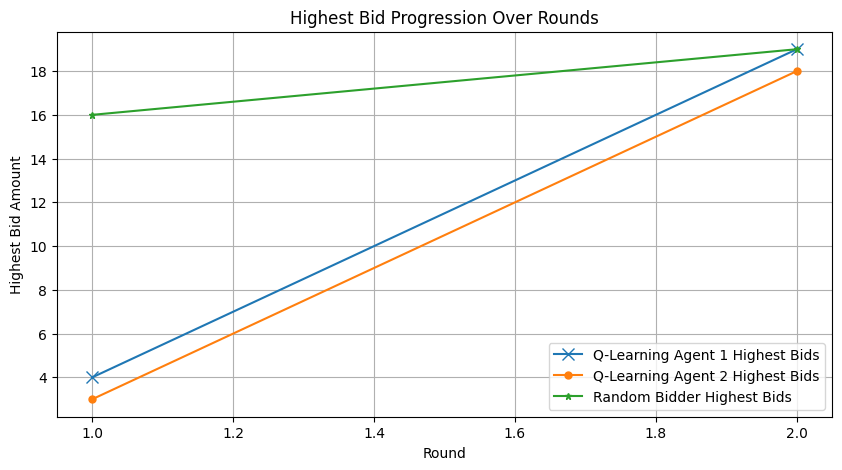

Reward for Q-Learning Agent 1: 0
Reward for Q-Learning Agent 2: 0


In [64]:

# Simulate and visualize a game
highest_bids_q1, highest_bids_q2, highest_bids_random, reward_q1, reward_q2 = play_game(q_table1, q_table2)
visualize_game(highest_bids_q1, highest_bids_q2, highest_bids_random)

print(f"Reward for Q-Learning Agent 1: {reward_q1}")
print(f"Reward for Q-Learning Agent 2: {reward_q2}")


### IID Valuations

Game 10000: Epsilon: 0.9901, Avg Q1: -3.1293, Avg Q2: -3.1465
Game 20000: Epsilon: 0.9802, Avg Q1: -3.1572, Avg Q2: -3.1216
Game 30000: Epsilon: 0.9704, Avg Q1: -3.0711, Avg Q2: -2.9815
Game 40000: Epsilon: 0.9608, Avg Q1: -3.1126, Avg Q2: -2.97
Game 50000: Epsilon: 0.9512, Avg Q1: -3.0255, Avg Q2: -2.9785
Game 60000: Epsilon: 0.9418, Avg Q1: -2.9323, Avg Q2: -2.9641
Game 70000: Epsilon: 0.9324, Avg Q1: -2.9408, Avg Q2: -2.9028
Game 80000: Epsilon: 0.9231, Avg Q1: -2.9411, Avg Q2: -2.8302
Game 90000: Epsilon: 0.9139, Avg Q1: -2.8851, Avg Q2: -2.8461
Game 100000: Epsilon: 0.9048, Avg Q1: -2.8049, Avg Q2: -2.8603
Game 110000: Epsilon: 0.8958, Avg Q1: -2.7909, Avg Q2: -2.8501
Game 120000: Epsilon: 0.8869, Avg Q1: -2.7377, Avg Q2: -2.7991
Game 130000: Epsilon: 0.8781, Avg Q1: -2.7316, Avg Q2: -2.741
Game 140000: Epsilon: 0.8694, Avg Q1: -2.7022, Avg Q2: -2.6462
Game 150000: Epsilon: 0.8607, Avg Q1: -2.6832, Avg Q2: -2.6098
Game 160000: Epsilon: 0.8521, Avg Q1: -2.5994, Avg Q2: -2.6186
Game

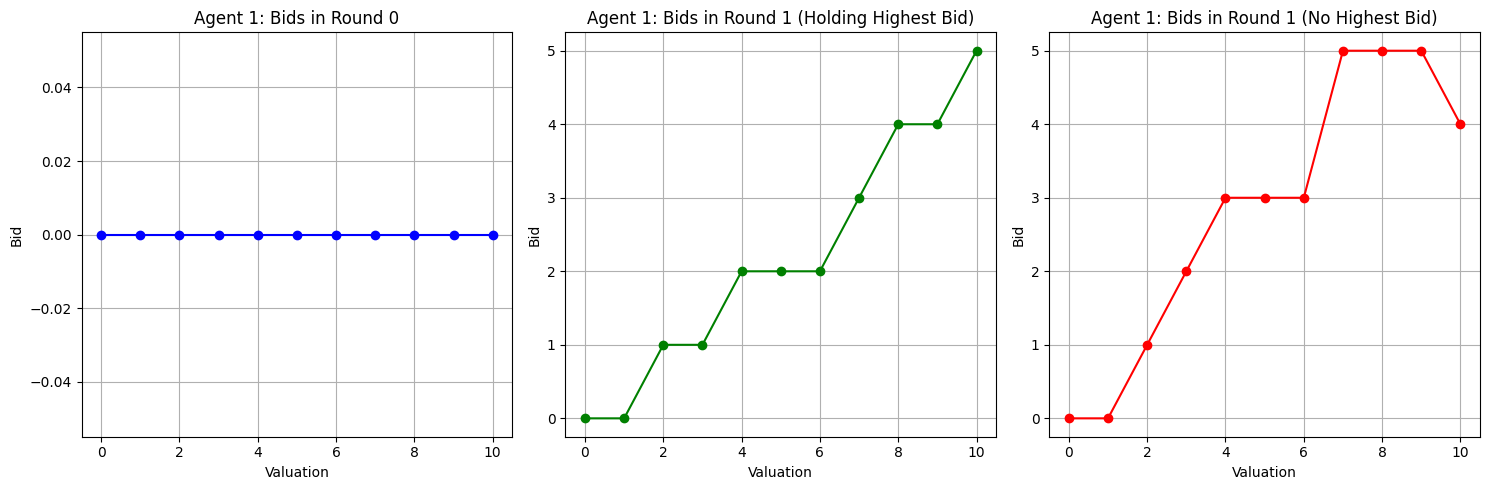

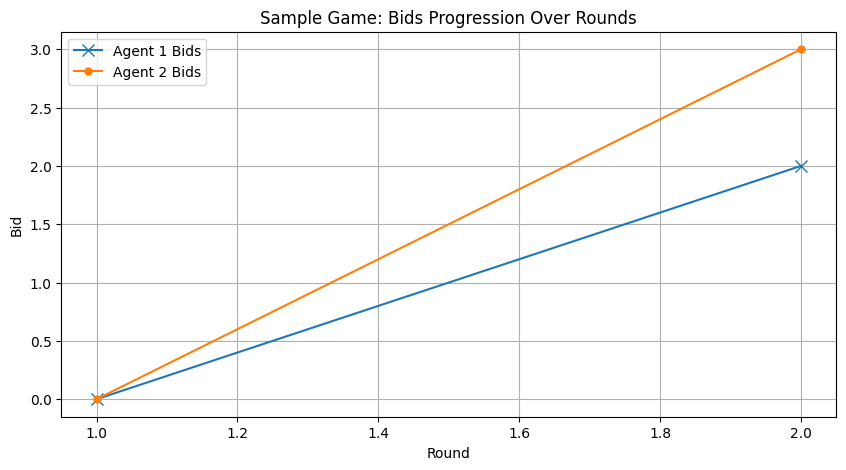

Agent 1 Valuation: 4, Agent 2 Valuation: 5
Agent 1 Final Bid: 2, Agent 2 Final Bid: 3
Agent 1 Reward: 0, Agent 2 Reward: 2


In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
num_actions = 10
actions = np.arange(num_actions)
epsilon_start = 1.0
epsilon_min = 0.01
epsilon_decay = 0.999999
learning_rate = 0.1
discount_rate = 1.0
lambda_ = 0.9
num_games = 3_000_000
verbose_interval = 10000

# Initialize Q-tables
q_table1 = np.ones((11, 3, num_actions))*11  # Q-table for Agent 1: (valuation, state, action)
q_table2 = np.ones((11, 3, num_actions))*11  # Q-table for Agent 2: (valuation, state, action)

# Train function for two agents with private valuations
def train_agents(q_table1, q_table2):
    epsilon = epsilon_start
    reward_history_q1 = []
    reward_history_q2 = []
    
    for game in range(num_games):
        e_trace1 = np.zeros_like(q_table1)
        e_trace2 = np.zeros_like(q_table2)

        current_bid_q1 = 0
        current_bid_q2 = 0

        v_q1 = np.random.randint(0, 11)  # Private valuation for agent 1
        v_q2 = np.random.randint(0, 11)  # Private valuation for agent 2

        # Round 0: s = 0 (start of the game)
        s_q1 = 0
        s_q2 = 0

        # Agent 1's action in round 0
        state_q1 = (v_q1, s_q1)
        action_q1 = np.random.choice(actions) if np.random.rand() < epsilon else actions[np.argmax(q_table1[state_q1])]
        current_bid_q1 += action_q1

        # Agent 2's action in round 0
        state_q2 = (v_q2, s_q2)
        action_q2 = np.random.choice(actions) if np.random.rand() < epsilon else actions[np.argmax(q_table2[state_q2])]
        current_bid_q2 += action_q2

        # Determine who holds the highest bid after round 0
        if current_bid_q1 == current_bid_q2:
            # Random tie-breaking: flip a coin
            s_q1 = np.random.choice([1, 2])  # Randomly decide who holds the highest bid
            s_q2 = 3 - s_q1  # Ensure the other agent gets the opposite state
        else:
            # No tie: the agent with the higher bid holds the highest bid
            s_q1 = 1 if current_bid_q1 > current_bid_q2 else 2
            s_q2 = 1 if current_bid_q2 > current_bid_q1 else 2

        # Round 1: s_q1 = 1 (if holding highest bid) or s_q1 = 2 (if not)
        state_q1 = (v_q1, s_q1)
        state_q2 = (v_q2, s_q2)

        action_q1 = np.random.choice(actions) if np.random.rand() < epsilon else actions[np.argmax(q_table1[state_q1])]
        action_q2 = np.random.choice(actions) if np.random.rand() < epsilon else actions[np.argmax(q_table2[state_q2])]

        current_bid_q1 += action_q1
        current_bid_q2 += action_q2

        # Eligibility trace update
        e_trace1 *= discount_rate * lambda_
        e_trace2 *= discount_rate * lambda_

        e_trace1[state_q1][action_q1] += 1
        e_trace2[state_q2][action_q2] += 1

        # Determine rewards after round 1
        if current_bid_q1 > current_bid_q2 or (current_bid_q1 == current_bid_q2 and np.random.choice([1, 0])):  # Agent 1 wins
            reward_q1 = v_q1 - current_bid_q1
            reward_q2 = 0
        else:  # Agent 2 wins
            reward_q1 = 0
            reward_q2 = v_q2 - current_bid_q2

        # Q-value update
        delta_q1 = reward_q1 - q_table1[state_q1][action_q1]
        delta_q2 = reward_q2 - q_table2[state_q2][action_q2]

        q_table1 += learning_rate * delta_q1 * e_trace1
        q_table2 += learning_rate * delta_q2 * e_trace2

        reward_history_q1.append(reward_q1)
        reward_history_q2.append(reward_q2)

        # Epsilon decay for exploration
        if (game + 1) % verbose_interval == 0:
            print(f"Game {game + 1}: Epsilon: {epsilon:.4f}, Avg Q1: {np.mean(reward_history_q1[-verbose_interval:])}, Avg Q2: {np.mean(reward_history_q2[-verbose_interval:])}")

        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    return q_table1, q_table2, reward_history_q1, reward_history_q2

# Function to visualize learned bidding function for Agent 1
def plot_learned_bidding_function(q_table1):
    valuations = np.arange(0, 11)

    bids_round0 = [actions[np.argmax(q_table1[(v, 0)])] for v in valuations]  # Round 0 bids
    bids_round1_highest = [actions[np.argmax(q_table1[(v, 1)])] for v in valuations]  # Round 1 with highest bid
    bids_round1_no_highest = [actions[np.argmax(q_table1[(v, 2)])] for v in valuations]  # Round 1 without highest bid

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))

    axs[0].plot(valuations, bids_round0, 'b-o', label='Round 0 Bids')
    axs[0].set_title('Agent 1: Bids in Round 0')
    axs[0].set_xlabel('Valuation')
    axs[0].set_ylabel('Bid')
    axs[0].grid(True)

    axs[1].plot(valuations, bids_round1_highest, 'g-o', label='Round 1 Bids (Highest Bid)')
    axs[1].set_title('Agent 1: Bids in Round 1 (Holding Highest Bid)')
    axs[1].set_xlabel('Valuation')
    axs[1].set_ylabel('Bid')
    axs[1].grid(True)

    axs[2].plot(valuations, bids_round1_no_highest, 'r-o', label='Round 1 Bids (No Highest Bid)')
    axs[2].set_title('Agent 1: Bids in Round 1 (No Highest Bid)')
    axs[2].set_xlabel('Valuation')
    axs[2].set_ylabel('Bid')
    axs[2].grid(True)

    plt.tight_layout()
    plt.show()

# Function to simulate a sample game between the two agents
def simulate_game(q_table1, q_table2):
    s = 0
    current_bid_q1 = 0
    current_bid_q2 = 0

    v_q1 = np.random.randint(0, 11)  # Private valuation for agent 1
    v_q2 = np.random.randint(0, 11)  # Private valuation for agent 2

    bids_q1 = []
    bids_q2 = []
    
    # Round 0 actions
    state_q1 = (v_q1, s)
    state_q2 = (v_q2, s)

    action_q1 = actions[np.argmax(q_table1[state_q1])]
    action_q2 = actions[np.argmax(q_table2[state_q2])]

    current_bid_q1 += action_q1
    current_bid_q2 += action_q2

    bids_q1.append(current_bid_q1)
    bids_q2.append(current_bid_q2)

    # Determine highest bidder after round 0
    if current_bid_q1 == current_bid_q2:
        s_q1 = np.random.choice([1, 2])
        s_q2 = 3 - s_q1
    else:
        s_q1 = 1 if current_bid_q1 > current_bid_q2 else 2
        s_q2 = 1 if current_bid_q2 > current_bid_q1 else 2

    # Round 1 actions
    state_q1 = (v_q1, s_q1)
    state_q2 = (v_q2, s_q2)

    action_q1 = actions[np.argmax(q_table1[state_q1])]
    action_q2 = actions[np.argmax(q_table2[state_q2])]

    current_bid_q1 += action_q1
    current_bid_q2 += action_q2

    bids_q1.append(current_bid_q1)
    bids_q2.append(current_bid_q2)

    # Determine rewards
    if current_bid_q1 > current_bid_q2 or (current_bid_q1 == current_bid_q2 and np.random.choice([1, 0])):  # Agent 1 wins
        reward_q1 = v_q1 - current_bid_q1
        reward_q2 = 0
    else:  # Agent 2 wins
        reward_q1 = 0
        reward_q2 = v_q2 - current_bid_q2

    plt.figure(figsize=(10, 5))
    plt.plot(range(1, 3), bids_q1, 'x-', label='Agent 1 Bids', markersize=8)
    plt.plot(range(1, 3), bids_q2, 'o-', label='Agent 2 Bids', markersize=5)
    plt.xlabel('Round')
    plt.ylabel('Bid')
    plt.title('Sample Game: Bids Progression Over Rounds')
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"Agent 1 Valuation: {v_q1}, Agent 2 Valuation: {v_q2}")
    print(f"Agent 1 Final Bid: {current_bid_q1}, Agent 2 Final Bid: {current_bid_q2}")
    print(f"Agent 1 Reward: {reward_q1}, Agent 2 Reward: {reward_q2}")

# Train the agents
q_table1, q_table2, reward_history_q1, reward_history_q2 = train_agents(q_table1, q_table2)

# Plot learned bidding function for Agent 1
plot_learned_bidding_function(q_table1)

# Simulate a sample game between the two agents
simulate_game(q_table1, q_table2)


### T rounds, K agents

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
num_actions = 10
actions = np.arange(num_actions)
epsilon_start = 1.0
epsilon_min = 0.01
epsilon_decay = 0.999999
learning_rate = 0.1
discount_rate = 1.0
lambda_ = 0.9
num_games = 3_000_000
verbose_interval = 10000

def initialize_q_tables(n_agents, max_valuation, n_rounds, num_actions):
    """Initialize Q-tables for all agents."""
    return [np.ones((max_valuation + 1, n_rounds, 2, num_actions)) * 11 for _ in range(n_agents)]

def train_agents(q_tables, n_rounds, n_agents, num_actions, num_games):
    """Train multiple agents over a given number of rounds."""
    epsilon = epsilon_start
    max_valuation = q_tables[0].shape[0] - 1  # Based on the shape of the Q-tables
    reward_history = {i: [] for i in range(n_agents)}

    for game in range(num_games):
        e_traces = [np.zeros_like(q_table) for q_table in q_tables]
        current_bids = np.zeros(n_agents)
        valuations = np.random.randint(0, max_valuation + 1, size=n_agents)  # Valuations for all agents

        states = [(v, 0, 0) for v in valuations]  # Initial states: round 0, s=0 for all agents

        # Play through the rounds
        for t in range(n_rounds):
            # Agents bid in this round
            for i in range(n_agents):
                v, _, s = states[i]
                state = (v, t, s)
                action = np.random.choice(actions) if np.random.rand() < epsilon else actions[np.argmax(q_tables[i][state])]
                current_bids[i] += action

            # Determine who holds the highest bid
            max_bid = np.max(current_bids)
            highest_bid_agents = np.where(current_bids == max_bid)[0]
            if len(highest_bid_agents) > 1:
                # Tie-breaking: randomly select one agent as the highest bidder
                chosen = np.random.choice(highest_bid_agents)
                for i in range(n_agents):
                    states[i] = (valuations[i], t, 1 if i == chosen else 0)
            else:
                for i in range(n_agents):
                    states[i] = (valuations[i], t, 1 if current_bids[i] == max_bid else 0)

        # Compute rewards after the final round
        final_bids = current_bids
        max_final_bid = np.max(final_bids)
        winners = np.where(final_bids == max_final_bid)[0]
        winner = np.random.choice(winners) if len(winners) > 1 else winners[0]

        for i in range(n_agents):
            reward = valuations[i] - final_bids[i] if i == winner else 0
            reward_history[i].append(reward)

            # Update Q-values
            v, t, s = states[i]
            state = (v, t, s)
            action = np.random.choice(actions) if np.random.rand() < epsilon else actions[np.argmax(q_tables[i][state])]
            delta = reward - q_tables[i][state][action]
            q_tables[i][state][action] += learning_rate * delta * e_traces[i][state][action]

        # Epsilon decay for exploration
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

        # Verbose output
        if (game + 1) % verbose_interval == 0:
            avg_rewards = [np.mean(reward_history[i][-verbose_interval:]) for i in range(n_agents)]
            print(f"Game {game + 1}: Epsilon: {epsilon:.4f}, Avg Rewards: {avg_rewards}")

    return q_tables, reward_history

def plot_learned_bidding_function(q_tables, n_agents, n_rounds):
    valuations = np.arange(0, q_tables[0].shape[0])

    fig, axs = plt.subplots(1, n_rounds, figsize=(15, 5))
    for t in range(n_rounds):
        for i in range(n_agents):
            bids_highest = [actions[np.argmax(q_tables[i][(v, t, 1)])] for v in valuations]
            bids_no_highest = [actions[np.argmax(q_tables[i][(v, t, 0)])] for v in valuations]

            axs[t].plot(valuations, bids_highest, 'g-o', label=f'Agent {i+1} Round {t+1} (Highest Bid)')
            axs[t].plot(valuations, bids_no_highest, 'r-o', label=f'Agent {i+1} Round {t+1} (No Highest Bid)')

        axs[t].set_title(f'Bidding in Round {t+1}')
        axs[t].set_xlabel('Valuation')
        axs[t].set_ylabel('Bid')
        axs[t].grid(True)
        axs[t].legend()

    plt.tight_layout()
    plt.show()

def simulate_game(q_tables, n_rounds, n_agents, num_actions):
    current_bids = np.zeros(n_agents)
    valuations = np.random.randint(0, q_tables[0].shape[0], size=n_agents)
    states = [(v, 0, 0) for v in valuations]

    bids_over_time = {i: [] for i in range(n_agents)}

    for t in range(n_rounds):
        for i in range(n_agents):
            v, _, s = states[i]
            state = (v, t, s)
            action = actions[np.argmax(q_tables[i][state])]
            current_bids[i] += action
            bids_over_time[i].append(current_bids[i])

        max_bid = np.max(current_bids)
        highest_bid_agents = np.where(current_bids == max_bid)[0]
        chosen = np.random.choice(highest_bid_agents) if len(highest_bid_agents) > 1 else highest_bid_agents[0]
        for i in range(n_agents):
            states[i] = (valuations[i], t, 1 if i == chosen else 0)

    for i in range(n_agents):
        plt.plot(range(1, n_rounds + 1), bids_over_time[i], label=f'Agent {i+1} Bids', markersize=8)

    plt.xlabel('Round')
    plt.ylabel('Bid')
    plt.title('Bids Progression Over Rounds')
    plt.legend()
    plt.grid(True)
    plt.show()

# Parameters
n_agents = 2  # Number of agents
n_rounds = 2  # Number of rounds
max_valuation = 10  # Maximum valuation
num_actions = 10  # Number of discrete actions
num_games = 3_000_000  # Number of games to train

# Initialize Q-tables
q_tables = initialize_q_tables(n_agents, max_valuation, n_rounds, num_actions)
q_tables, reward_history = train_agents(q_tables, n_rounds, n_agents, num_actions, num_games)
plot_learned_bidding_function(q_tables, n_agents, n_rounds)
simulate_game(q_tables, n_rounds, n_agents, num_actions)